<a href="https://colab.research.google.com/github/haripranavks7/STUDENT-PERFORMANCE-PREDICTION/blob/main/SPP_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Save model
import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [3]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 395
Number of columns: 33

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


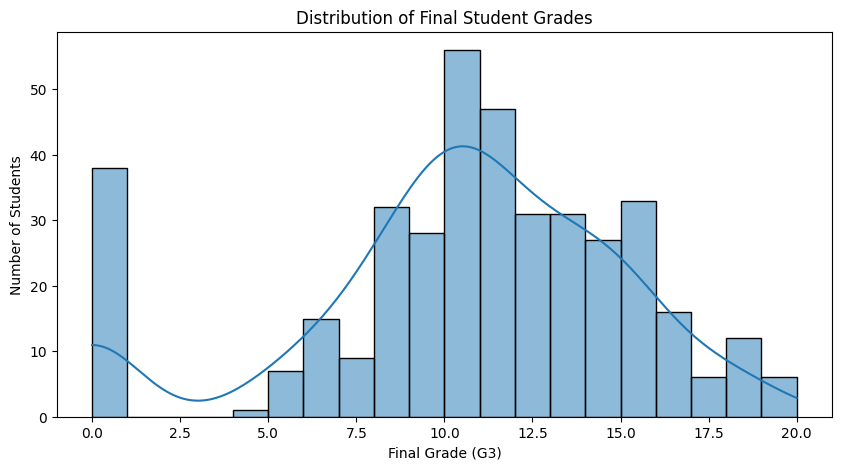

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

In [10]:
def performance_category(grade):
    if grade < 10:
        return "Poor"
    elif grade < 12:
        return "Average"
    elif grade < 16:
        return "Good"
    else:
        return "Excellent"

df["performance"] = df["G3"].apply(performance_category)

df[["G3", "performance"]].head(20)

,G3,performance
0,6,Poor
1,6,Poor
2,10,Average
3,15,Good
4,10,Average
5,15,Good
6,11,Average
7,6,Poor
8,19,Excellent
9,15,Good


performance
Poor         130
Good         122
Average      103
Excellent     40
Name: count, dtype: int64


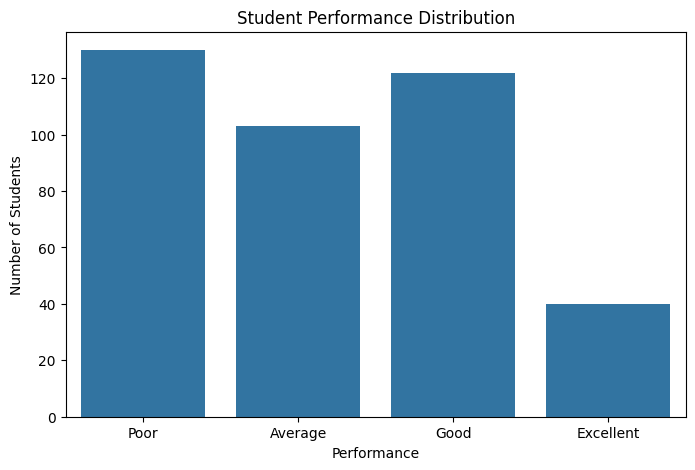

In [11]:
print(df["performance"].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="performance",
    order=["Poor", "Average", "Good", "Excellent"]
)

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

In [12]:
features = [
    "school",
    "sex",
    "age",
    "address",
    "famsize",
    "Pstatus",
    "Medu",
    "Fedu",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "traveltime",
    "studytime",
    "failures",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences"
]

X = df[features]

y = df["performance"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (395, 30)
Target shape: (395,)


In [14]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


In [16]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [17]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

     Average       0.20      0.19      0.20        21
   Excellent       0.50      0.12      0.20         8
        Good       0.31      0.33      0.32        24
        Poor       0.48      0.58      0.53        26

    accuracy                           0.35        79
   macro avg       0.37      0.31      0.31        79
weighted avg       0.36      0.35      0.34        79



In [18]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

     Average       0.21      0.14      0.17        21
   Excellent       0.50      0.12      0.20         8
        Good       0.40      0.42      0.41        24
        Poor       0.37      0.54      0.44        26

    accuracy                           0.35        79
   macro avg       0.37      0.31      0.30        79
weighted avg       0.35      0.35      0.33        79



In [19]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

              precision    recall  f1-score   support

     Average       0.33      0.24      0.28        21
   Excellent       0.33      0.12      0.18         8
        Good       0.36      0.38      0.37        24
        Poor       0.47      0.65      0.55        26

    accuracy                           0.41        79
   macro avg       0.37      0.35      0.34        79
weighted avg       0.39      0.41      0.38        79



In [20]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

     Average       0.00      0.00      0.00        21
   Excellent       0.00      0.00      0.00         8
        Good       0.29      0.38      0.33        24
        Poor       0.46      0.69      0.55        26

    accuracy                           0.34        79
   macro avg       0.19      0.27      0.22        79
weighted avg       0.24      0.34      0.28        79



In [21]:
models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "SVM": y_pred_svm
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Gradient Boosting,0.405063,0.387145,0.405063,0.384333
0,Logistic Regression,0.354430,0.356522,0.354430,0.342554
1,Random Forest,0.354430,0.350366,0.354430,0.333809
3,SVM,0.341772,0.240098,0.341772,0.281703


In [22]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best model:", best_model_name)

Best model: Gradient Boosting


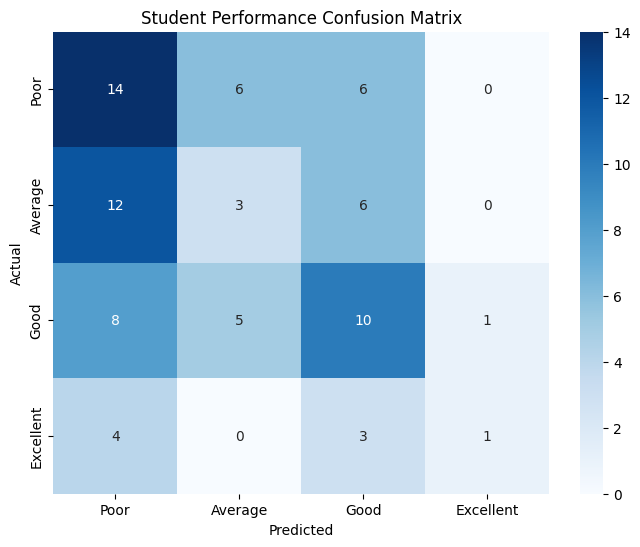

In [23]:
best_model = rf_model

y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "Poor",
        "Average",
        "Good",
        "Excellent"
    ]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Poor",
        "Average",
        "Good",
        "Excellent"
    ],
    yticklabels=[
        "Poor",
        "Average",
        "Good",
        "Excellent"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Student Performance Confusion Matrix")

plt.show()

In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     Average       0.21      0.14      0.17        21
   Excellent       0.50      0.12      0.20         8
        Good       0.40      0.42      0.41        24
        Poor       0.37      0.54      0.44        26

    accuracy                           0.35        79
   macro avg       0.37      0.31      0.30        79
weighted avg       0.35      0.35      0.33        79



In [25]:
n_estimators=300

In [26]:
param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        15
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [27]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'Medu',
                                                                          'Fedu',
                                                                          'traveltime',
                                                                          'studytime',
                                                                          'failures',
                                                                          'famrel',
                                                                          'freetime',
                                                                          'goout',
                                                                          'Dalc',
                                                                          'Walc',
                                                                          'health',
                                                                          'absences']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['school'...
                                                                          'nursery',
                                                                          'higher',
                                                                          'internet',
                                                                          'romantic'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=300,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10, 15],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='f1_weighted', verbose=1)

In [28]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Best cross-validation F1 score:
0.4151172825712216


In [29]:
final_model = grid_search.best_estimator_

final_predictions = final_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

     Average       0.29      0.19      0.23        21
   Excellent       0.33      0.25      0.29         8
        Good       0.40      0.42      0.41        24
        Poor       0.44      0.58      0.50        26

    accuracy                           0.39        79
   macro avg       0.37      0.36      0.36        79
weighted avg       0.38      0.39      0.38        79



In [30]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

print("Final Model Performance")
print("-----------------------")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

Final Model Performance
-----------------------
Accuracy  : 0.3924
Precision : 0.3764
Recall    : 0.3924
F1 Score  : 0.3782


In [31]:
rf_classifier = final_model.named_steps[
    "classifier"
]

feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance_df.head(20)

,Feature,Importance
12,num__absences,0.067422
1,num__Medu,0.048983
5,num__failures,0.044771
11,num__health,0.041577
0,num__age,0.040429
8,num__goout,0.040426
2,num__Fedu,0.036970
10,num__Walc,0.036023
7,num__freetime,0.033293
4,num__studytime,0.031125


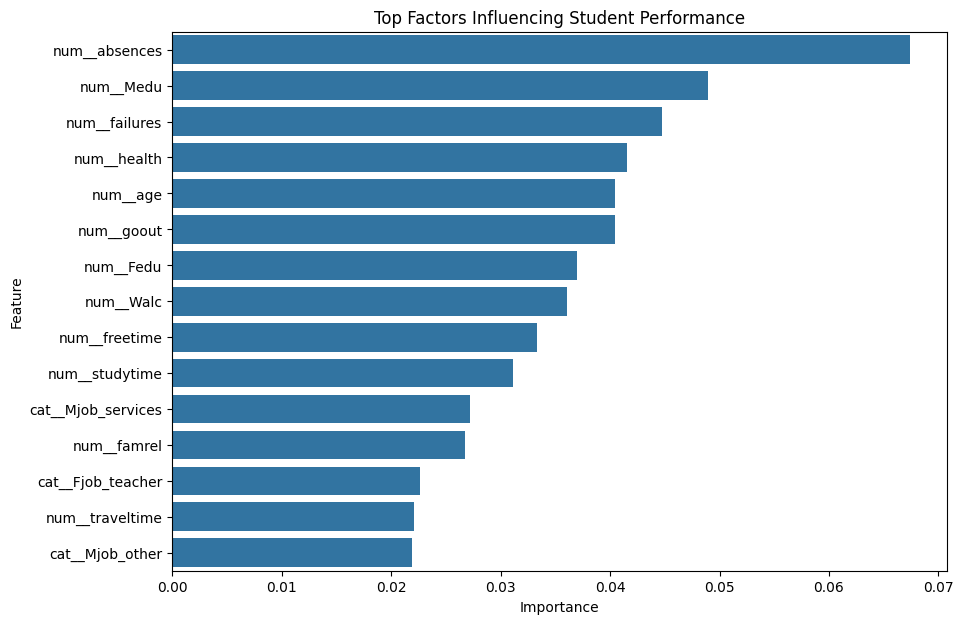

In [32]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Factors Influencing Student Performance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [33]:
joblib.dump(
    final_model,
    "student_performance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [34]:
from google.colab import files

files.download(
    "student_performance_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
def predict_student_performance(student_data):

    input_df = pd.DataFrame(
        [student_data]
    )

    prediction = final_model.predict(
        input_df
    )[0]

    probability = final_model.predict_proba(
        input_df
    )[0]

    classes = final_model.classes_

    probabilities = dict(
        zip(classes, probability)
    )

    return prediction, probabilities

In [36]:
student = {
    "school": "GP",
    "sex": "M",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "A",
    "Medu": 4,
    "Fedu": 4,
    "Mjob": "teacher",
    "Fjob": "services",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 1,
    "studytime": 4,
    "failures": 0,
    "schoolsup": "yes",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 5,
    "freetime": 3,
    "goout": 2,
    "Dalc": 1,
    "Walc": 1,
    "health": 5,
    "absences": 2
}

prediction, probabilities = predict_student_performance(
    student
)

print("Predicted Performance:", prediction)

print("\nPrediction Probabilities:")

for category, probability in probabilities.items():
    print(
        f"{category}: {probability:.2%}"
    )

Predicted Performance: Poor

Prediction Probabilities:
Average: 29.59%
Excellent: 20.59%
Good: 16.89%
Poor: 32.94%
